# Sorcha ROC Comparison — VDP vs digest2

Head-to-head comparison of the VDP probability-map classifier vs digest2 on ~606K tracklets
from the Sorcha-based reproduction of the Wagg et al. 2024 Rubin/NEOCP simulation.

**This run uses the hybrid-training maps** (S3M NEO density + MPCORB MBA density),
24 monthly antisun maps covering May 2025 – Apr 2027, velocity grid ±3 deg/day.

Pre-computed scores are in `outputs/phase2/sorcha_comparison_hybrid.parquet`.

| Pass | VDP F1 | digest2 F1 | Gap |
|---|---|---|---|
| 5 maps, 2 epochs (first pass) | 0.342 | ~0.79 | 0.45 |
| 24 monthly maps + all fixes, grid ±1.5 | 0.740 | 0.836 | 0.096 |
| **Hybrid training, grid ±3** | **0.803** | **0.837** | **0.034** |


In [17]:
# Optional: re-run the full pipeline from this notebook (slow)
# The script now chunks digest2 calls, so the full run can take about an hour.
# %run run_digest2_comparison.py


## 1. Setup

In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

_HERE = os.path.abspath('.')
PARQUET = os.path.join(_HERE, 'outputs/phase2/sorcha_comparison_gmm.parquet')
FIG_OUT = os.path.join(_HERE, 'outputs/phase2/roc_comparison_wagg_sorcha_gmm.png')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})


## 2. Load results

In [30]:
df = pd.read_parquet(PARQUET)
print(f'{len(df):,} tracklets')
print(df['population'].value_counts().to_string())

pops = ['NEO', 'MBA', 'Trojan', 'TNO', 'other']
colors = {'NEO': 'tab:blue', 'MBA': 'tab:orange', 'TNO': 'tab:green',
          'Trojan': 'tab:red', 'other': 'tab:purple'}
df.head()


# Drop rows that were not VDP-scored (legacy lon229_lat0 map, 3,933 rows)
df = df[df['P_NEO_vdp'].notna()].reset_index(drop=True)
print(f'After dropping unscored rows: {len(df):,} tracklets')


611,041 tracklets
population
MBA       455726
NEO       113812
other      21387
Trojan     14152
TNO         5964
After dropping unscored rows: 597,506 tracklets


## 3. Score distributions

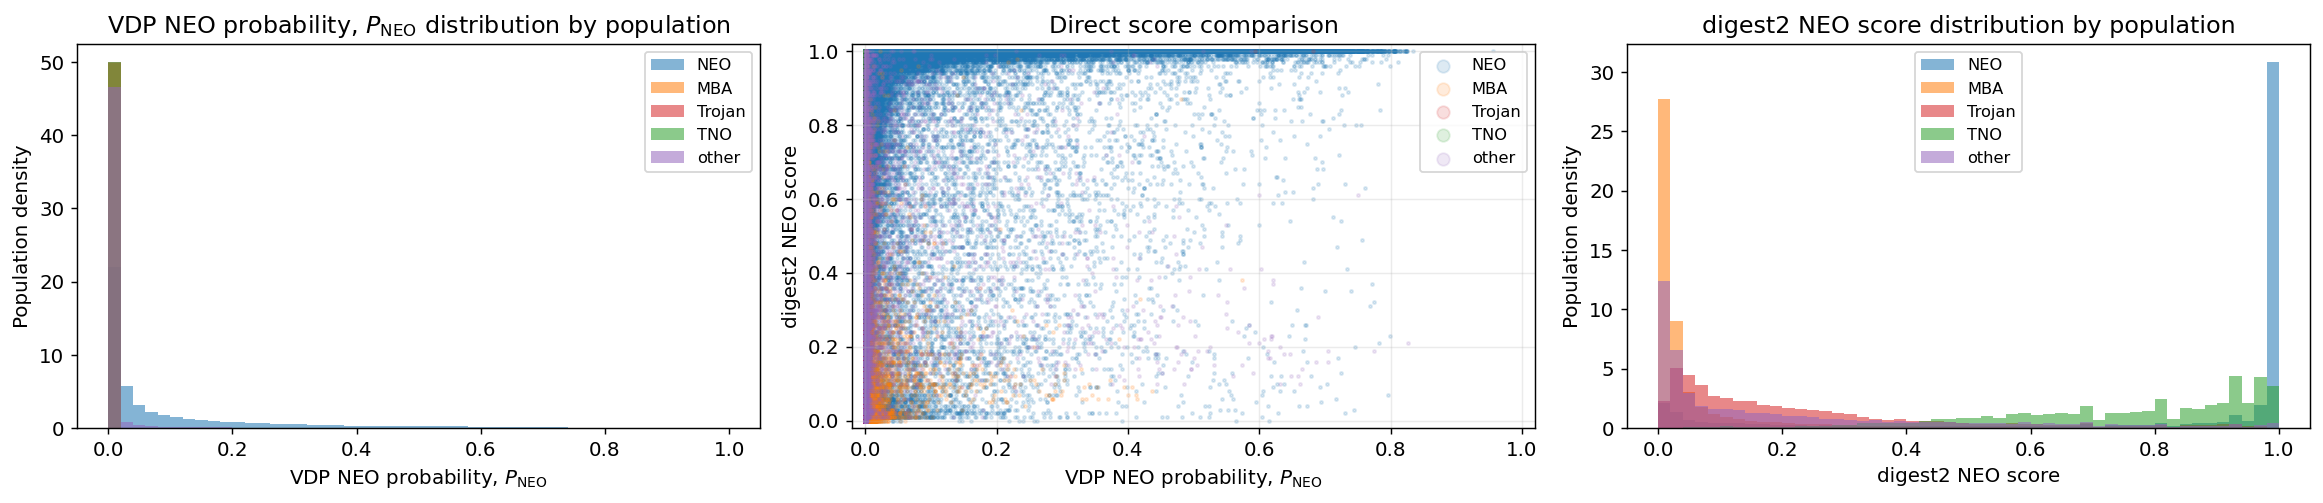

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

hist_specs = [
    (axes[0], 'P_NEO_vdp', 'VDP NEO probability, $P_{\mathrm{NEO}}$'),
    (axes[2], 'P_NEO_d2',  'digest2 NEO score'),
]

for ax, col, label in hist_specs:
    for pop in pops:
        sub = df.loc[df.population == pop, col]
        ax.hist(sub, bins=50, alpha=0.55, label=pop, color=colors.get(pop),
                density=True, range=(0, 1))
    ax.set_xlabel(label)
    ax.set_ylabel('Population density')
    ax.set_title(f'{label} distribution by population')
    ax.legend(fontsize=9)

ax = axes[1]
for pop in pops:
    sub = df[df.population == pop]
    ax.scatter(sub['P_NEO_vdp'], sub['P_NEO_d2'], s=3, alpha=0.15,
               label=pop, color=colors.get(pop), rasterized=True)
ax.set_xlabel('VDP NEO probability, $P_{\mathrm{NEO}}$')
ax.set_ylabel('digest2 NEO score')
ax.set_title('Direct score comparison')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=9, markerscale=4)

plt.tight_layout()
plt.show()
plt.close(fig)


## 4. ROC curves

In [32]:
is_neo = (df['population'] == 'NEO').to_numpy()
N_neo  = is_neo.sum()
N_non  = (~is_neo).sum()
print(f'N_NEO={N_neo:,}  N_non-NEO={N_non:,}')

thresholds = np.linspace(0, 1, 401)

def compute_roc(scores, is_neo, thresholds):
    """Sweep thresholds; uses is_neo.sum() as denominator (self-contained)."""
    N_pos = is_neo.sum()
    comp = np.empty(len(thresholds))
    cont = np.empty(len(thresholds))
    for j, t in enumerate(thresholds):
        above = scores > t
        tp = above[is_neo].sum()
        fp = above[~is_neo].sum()
        comp[j] = tp / max(N_pos, 1)
        cont[j] = fp / max(tp + fp, 1)
    return comp, cont

def best_f1(comp, cont, thr):
    pur = 1 - cont
    f1  = np.where(pur + comp > 0, 2*pur*comp/(pur + comp + 1e-12), 0.0)
    i   = np.argmax(f1)
    return thr[i], comp[i], cont[i], f1[i]

comp_v, cont_v = compute_roc(df['P_NEO_vdp'].to_numpy(), is_neo, thresholds)
comp_d, cont_d = compute_roc(df['P_NEO_d2'].to_numpy(),  is_neo, thresholds)

tv, cv, nv, fv = best_f1(comp_v, cont_v, thresholds)
td, cd, nd, fd = best_f1(comp_d, cont_d, thresholds)

print(f'VDP     best: t={tv:.3f}  completeness={cv:.1%}  contamination={nv:.1%}  F1={fv:.3f}')
print(f'Digest2 best: t={td:.3f}  completeness={cd:.1%}  contamination={nd:.1%}  F1={fd:.3f}')


N_NEO=109,589  N_non-NEO=487,917
VDP     best: t=0.003  completeness=78.3%  contamination=10.2%  F1=0.837
Digest2 best: t=0.640  completeness=77.3%  contamination=8.8%  F1=0.837


Saved: /astro/users/ds2004/vdp/outputs/phase2/roc_comparison_wagg_sorcha_gmm.png


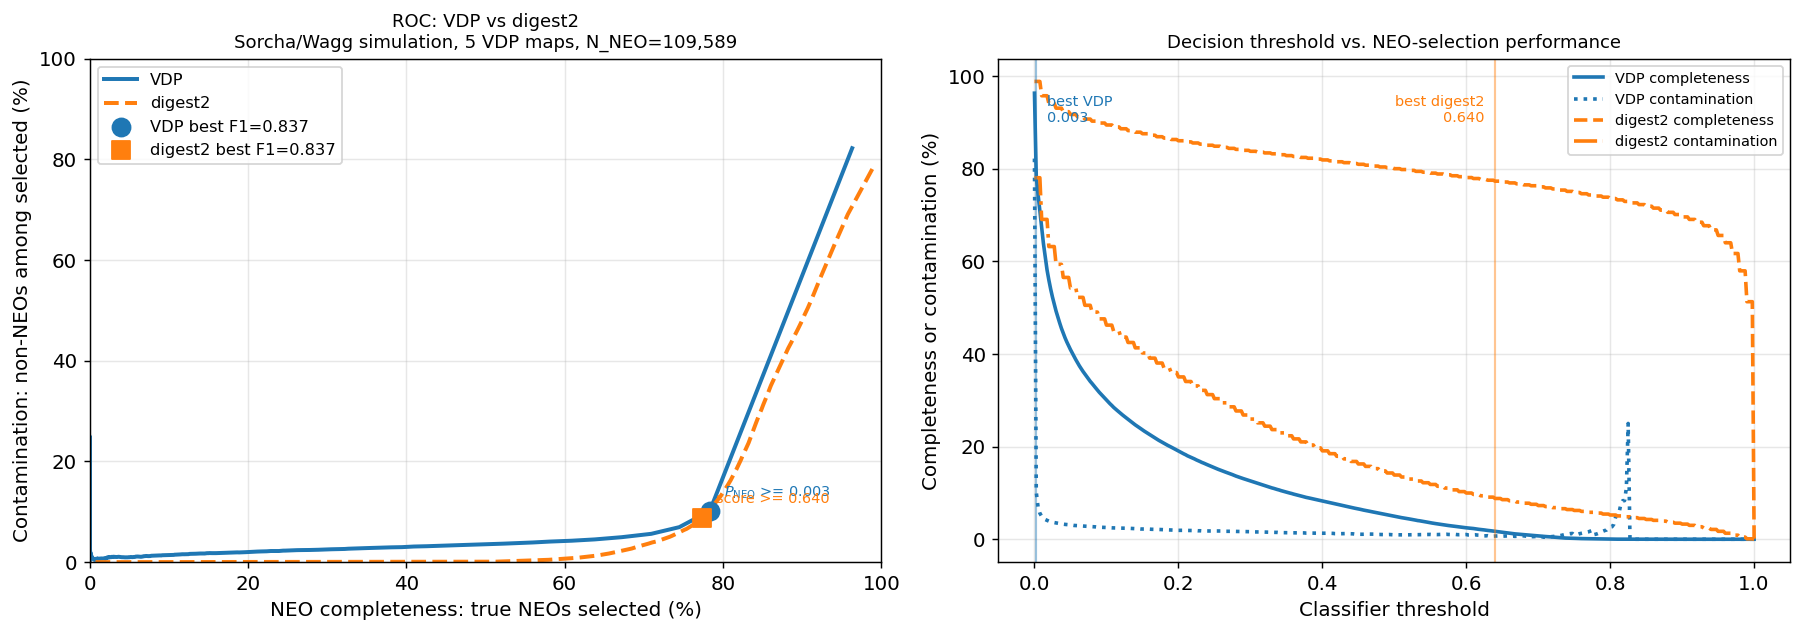

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(comp_v*100, cont_v*100, lw=2.2, color='tab:blue', label='VDP')
ax.plot(comp_d*100, cont_d*100, lw=2.2, color='tab:orange', linestyle='--', label='digest2')
ax.scatter([cv*100], [nv*100], color='tab:blue', s=100, zorder=5, label=f'VDP best F1={fv:.3f}')
ax.scatter([cd*100], [nd*100], color='tab:orange', s=100, zorder=5, marker='s', label=f'digest2 best F1={fd:.3f}')
ax.annotate(f'$P_{{\mathrm{{NEO}}}}$ >= {tv:.3f}', xy=(cv*100, nv*100), xytext=(8, 8),
            textcoords='offset points', color='tab:blue', fontsize=8)
ax.annotate(f'score >= {td:.3f}', xy=(cd*100, nd*100), xytext=(8, 8),
            textcoords='offset points', color='tab:orange', fontsize=8)
ax.set_xlabel('NEO completeness: true NEOs selected (%)')
ax.set_ylabel('Contamination: non-NEOs among selected (%)')
ax.set_title(f'ROC: VDP vs digest2\nSorcha/Wagg simulation, 5 VDP maps, N_NEO={N_neo:,}', fontsize=10)
ax.legend(fontsize=9, frameon=True, loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)

ax = axes[1]
ax.plot(thresholds, comp_v*100, lw=2, color='tab:blue', label='VDP completeness')
ax.plot(thresholds, cont_v*100, lw=2, color='tab:blue', linestyle=':', label='VDP contamination')
ax.plot(thresholds, comp_d*100, lw=2, color='tab:orange', linestyle='--', label='digest2 completeness')
ax.plot(thresholds, cont_d*100, lw=2, color='tab:orange', linestyle='-.', label='digest2 contamination')
ax.axvline(tv, color='tab:blue', alpha=0.45, lw=1.2)
ax.axvline(td, color='tab:orange', alpha=0.45, lw=1.2)
ax.text(tv + 0.015, 96, f'best VDP\n{tv:.3f}', color='tab:blue', fontsize=8, va='top')
ax.text(td - 0.015, 96, f'best digest2\n{td:.3f}', color='tab:orange', fontsize=8, va='top', ha='right')
ax.set_xlabel('Classifier threshold')
ax.set_ylabel('Completeness or contamination (%)')
ax.set_title('Decision threshold vs. NEO-selection performance', fontsize=10)
ax.legend(fontsize=8, frameon=True, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_OUT, dpi=150, bbox_inches='tight')
print(f'Saved: {FIG_OUT}')
plt.show()
plt.close(fig)


## 5. Score-threshold quadrants

The direct score comparison becomes more useful if we draw the best-F1 decision thresholds from the ROC section. These four quadrants show where VDP and digest2 agree, and where each classifier uniquely selects candidates.

population,MBA,NEO,TNO,Trojan,other,total,NEO fraction
score_quadrant,,,,,,,
both select,127,77402,1,2,861,78393,98.7%
VDP only,6577,8438,0,5,2147,17167,49.2%
digest2 only,1099,7554,4120,1105,1185,15063,50.1%
neither selects,439364,16195,1695,12820,16809,486883,3.3%


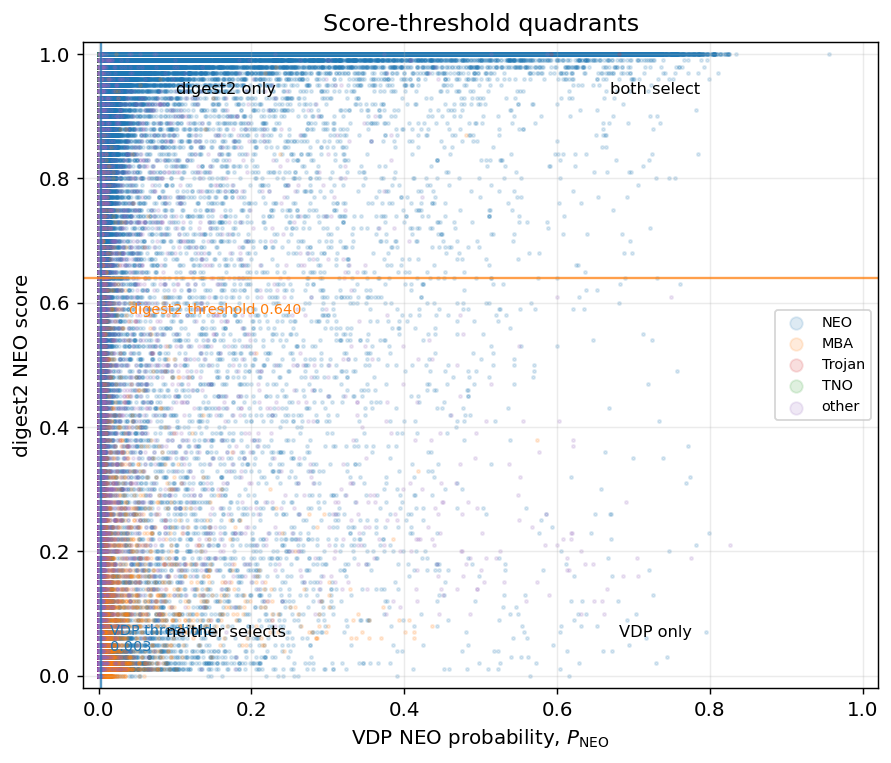

In [34]:
vdp_selected = df['P_NEO_vdp'] >= tv
d2_selected  = df['P_NEO_d2']  >= td

quadrant_labels = np.select(
    [vdp_selected & d2_selected, vdp_selected & ~d2_selected, ~vdp_selected & d2_selected],
    ['both select', 'VDP only', 'digest2 only'],
    default='neither selects',
)

quad_df = df.assign(score_quadrant=quadrant_labels)
quad_summary = (
    quad_df
    .groupby(['score_quadrant', 'population'])
    .size()
    .unstack(fill_value=0)
    .reindex(['both select', 'VDP only', 'digest2 only', 'neither selects'])
)
quad_summary['total'] = quad_summary.sum(axis=1)
quad_summary['NEO fraction'] = (quad_summary.get('NEO', 0) / quad_summary['total']).map('{:.1%}'.format)
display(quad_summary)

fig, ax = plt.subplots(figsize=(7, 6))
for pop in pops:
    sub = df[df.population == pop]
    ax.scatter(sub['P_NEO_vdp'], sub['P_NEO_d2'], s=3, alpha=0.15,
               label=pop, color=colors.get(pop), rasterized=True)

ax.axvline(tv, color='tab:blue', lw=1.3, alpha=0.75)
ax.axhline(td, color='tab:orange', lw=1.3, alpha=0.75)
ax.text(tv + 0.012, 0.04, f'VDP threshold\n{tv:.3f}', color='tab:blue', fontsize=8)
ax.text(0.04, td - 0.04, f'digest2 threshold {td:.3f}', color='tab:orange', fontsize=8, va='top')
ax.text(0.72, 0.92, 'both select',     transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.72, 0.08, 'VDP only',        transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.18, 0.92, 'digest2 only',    transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.18, 0.08, 'neither selects', transform=ax.transAxes, fontsize=9, ha='center')
ax.set_xlabel('VDP NEO probability, $P_{\mathrm{NEO}}$')
ax.set_ylabel('digest2 NEO score')
ax.set_title('Score-threshold quadrants')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, markerscale=4, loc='center right')
plt.tight_layout()
plt.show()
plt.close(fig)


## 6. 2D score density

The scatter plot hides the density near zero because many objects overlap. Hexbin views show the same score space as density, first for all objects and then split into true NEO and non-NEO samples.

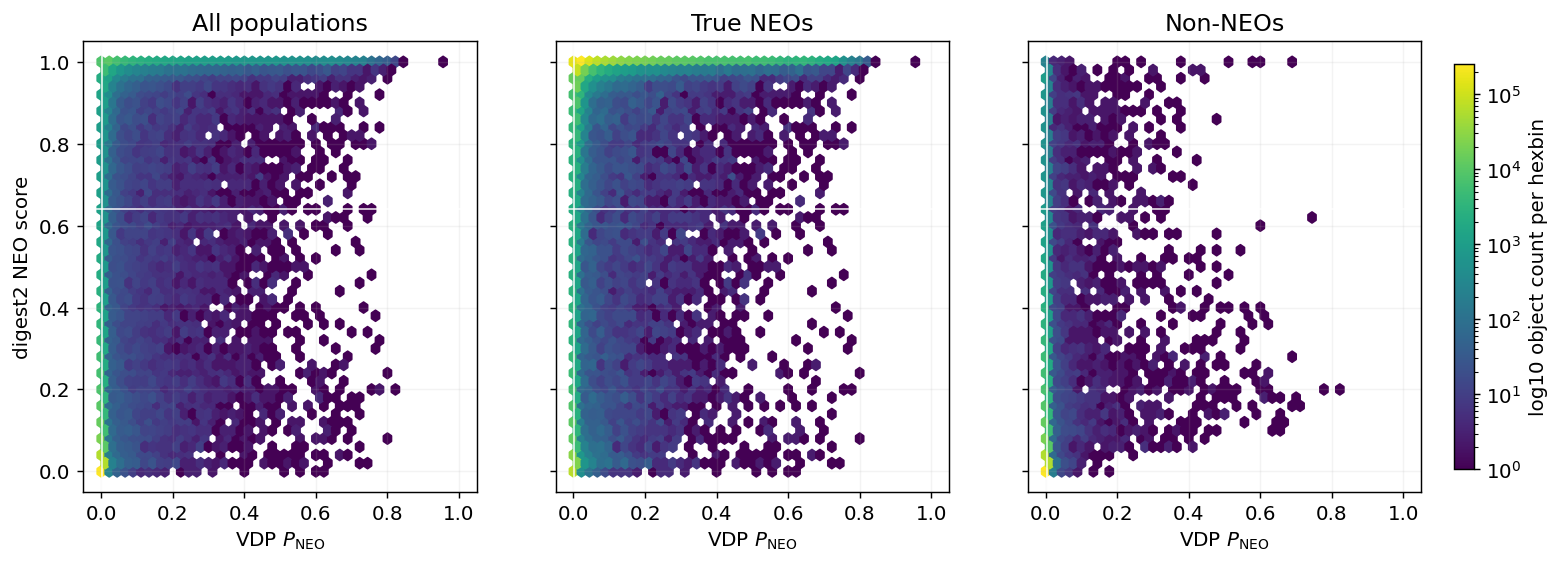

In [35]:
density_views = [
    ('All populations', np.ones(len(df), dtype=bool)),
    ('True NEOs', is_neo),
    ('Non-NEOs', ~is_neo),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
for ax, (title, mask) in zip(axes, density_views):
    hb = ax.hexbin(
        df.loc[mask, 'P_NEO_vdp'],
        df.loc[mask, 'P_NEO_d2'],
        gridsize=45,
        extent=(0, 1, 0, 1),
        bins='log',
        mincnt=1,
        cmap='viridis',
    )
    ax.axvline(tv, color='white', lw=1.0, alpha=0.8)
    ax.axhline(td, color='white', lw=1.0, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('VDP $P_{\mathrm{NEO}}$')
    ax.grid(alpha=0.15)
axes[0].set_ylabel('digest2 NEO score')
cbar = fig.colorbar(hb, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label('log10 object count per hexbin')
plt.show()
plt.close(fig)

## 8. Per-population score breakdown

In [36]:
for pop in sorted(df.population.unique()):
    sub = df[df.population == pop]
    vdp_med = sub.P_NEO_vdp.median()
    d2_med  = sub.P_NEO_d2.median()
    vdp_hi  = (sub.P_NEO_vdp > tv).mean()
    d2_hi   = (sub.P_NEO_d2  > td).mean()
    print(f'{pop:10s}  n={len(sub):6,}  '
          f'VDP median={vdp_med:.4f}  above_thr={vdp_hi:.1%}  '
          f'| d2 median={d2_med:.4f}  above_thr={d2_hi:.1%}')


MBA         n=447,167  VDP median=0.0001  above_thr=1.5%  | d2 median=0.0100  above_thr=0.2%
NEO         n=109,589  VDP median=0.0287  above_thr=78.3%  | d2 median=1.0000  above_thr=77.3%
TNO         n= 5,816  VDP median=0.0000  above_thr=0.0%  | d2 median=0.8000  above_thr=69.5%
Trojan      n=13,932  VDP median=0.0000  above_thr=0.1%  | d2 median=0.1500  above_thr=7.6%
other       n=21,002  VDP median=0.0001  above_thr=14.3%  | d2 median=0.0900  above_thr=9.4%


## 9. Explore: VDP score vs. observable properties

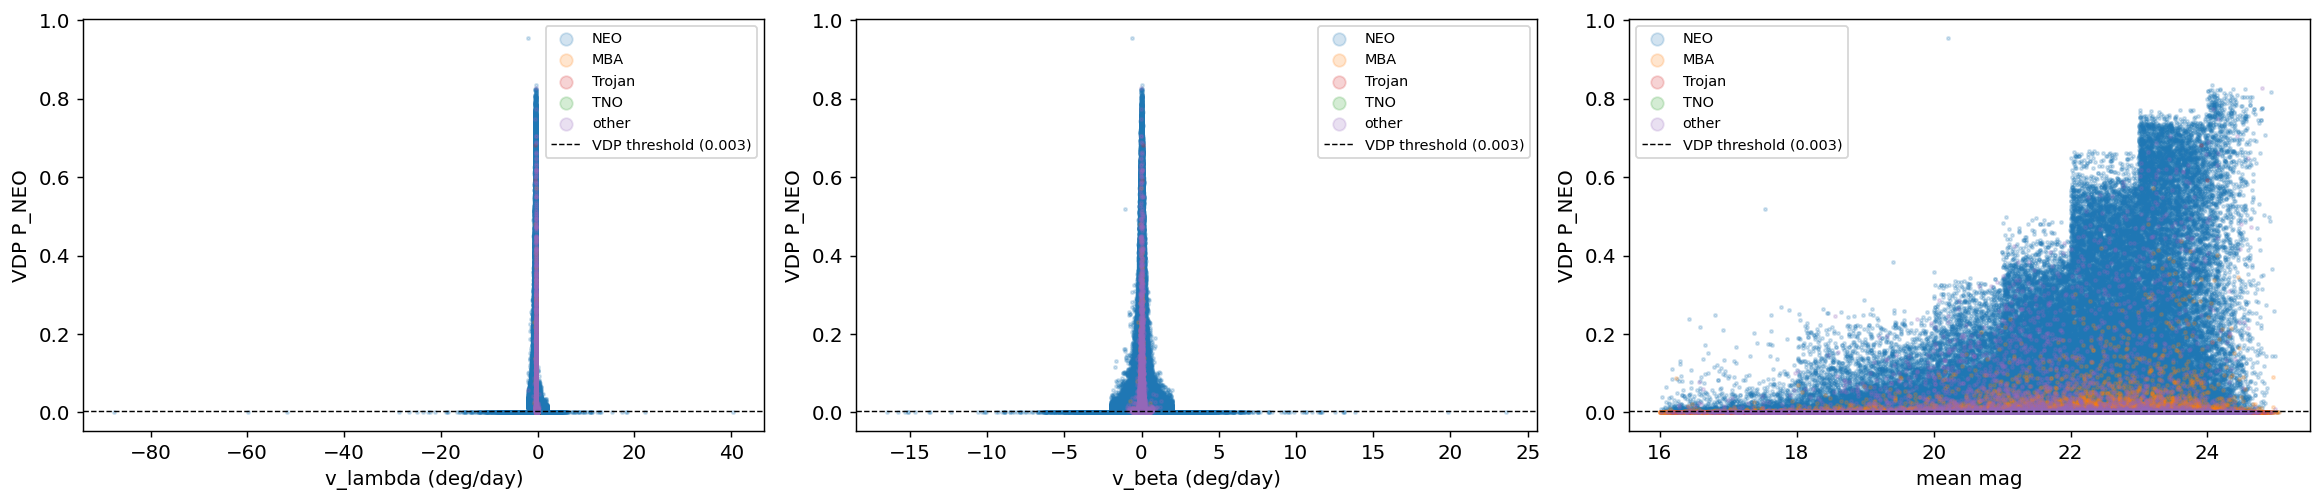

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (xcol, xlabel) in zip(
    axes,
    [('vlam', 'v_lambda (deg/day)'), ('vbeta', 'v_beta (deg/day)'), ('mean_mag', 'mean mag')]
):
    for pop in pops:
        sub = df[df.population == pop]
        ax.scatter(sub[xcol], sub['P_NEO_vdp'], s=3, alpha=0.2,
                   label=pop, color=colors.get(pop))
    ax.axhline(tv, color='k', lw=0.8, linestyle='--', label=f'VDP threshold ({tv:.3f})')
    ax.set_xlabel(xlabel); ax.set_ylabel('VDP P_NEO')
    ax.legend(fontsize=8, markerscale=4)

plt.tight_layout()
plt.show()
plt.close(fig)


### Direct score comparison

This single-panel view puts the two classifier scores against each other for the same objects. The threshold lines mark the best-F1 operating points from the ROC section.

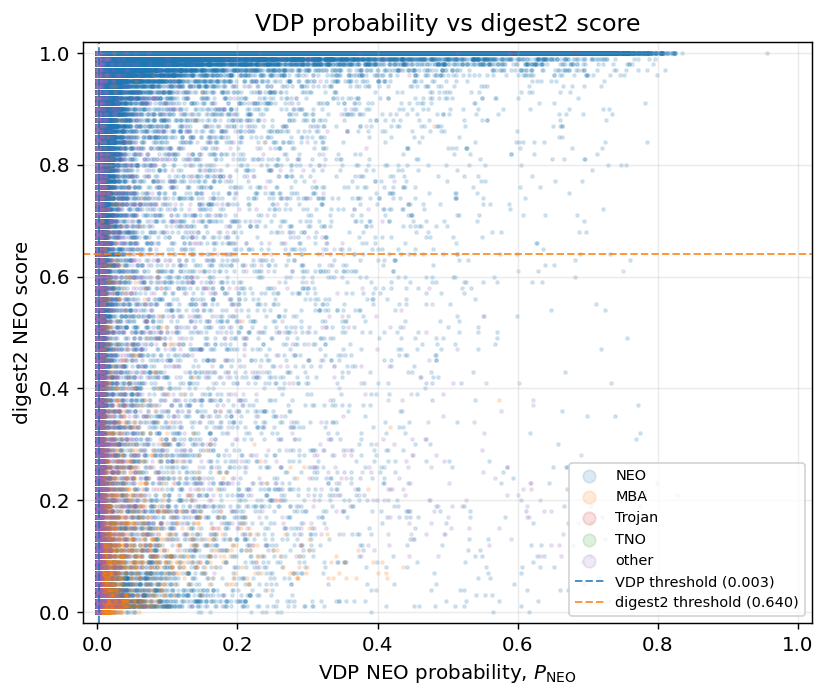

In [38]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for pop in pops:
    sub = df[df.population == pop]
    ax.scatter(sub['P_NEO_vdp'], sub['P_NEO_d2'], s=3, alpha=0.15,
               label=pop, color=colors.get(pop), rasterized=True)

ax.axvline(tv, color='tab:blue',   lw=1.1, alpha=0.8, linestyle='--', label=f'VDP threshold ({tv:.3f})')
ax.axhline(td, color='tab:orange', lw=1.1, alpha=0.8, linestyle='--', label=f'digest2 threshold ({td:.3f})')
ax.set_xlabel('VDP NEO probability, $P_{\mathrm{NEO}}$')
ax.set_ylabel('digest2 NEO score')
ax.set_title('VDP probability vs digest2 score')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, markerscale=4, loc='lower right')
plt.tight_layout()
plt.show()
plt.close(fig)
